# Notebook 09: Meson Correlators and Masses

**Learning objectives:**
- Understand meson operators ($\pi$, $\sigma$, $\rho$) and their quantum numbers
- Calculate meson two-point correlators $C(t)$
- Extract effective masses $m_{\rm eff}(t) = \ln[C(t)/C(t+1)]$
- Fit the plateau to obtain the ground-state mass
- Study the pion mass vs quark mass (GMOR relation)
- Compare the $\pi$, $\sigma$, $\rho$ mass hierarchy

**Prerequisites:** Notebooks 06-08

**From modular code:** `MesonBase.get_meson_gamma_matrix()`, `PionCalculator.calculate_pion_mass()`,
`SigmaCalculator.calculate_sigma_mass()`, `RhoCalculator.calculate_rho_mass()`,
`MesonIntegration.calculate_meson_spectrum()`

In [1]:
#import os
#os._exit(00)


In [2]:
from notebook_utils import setup_paths, load_config, plot_correlator, plot_effective_mass
REPO = setup_paths()

import os
import numpy as np
import matplotlib.pyplot as plt
import su2
from MesonBase import (get_meson_gamma_matrix,
                       build_wilson_dirac_matrix,
                       generate_identity_gauge_field,
                       create_point_source,
                       solve_dirac_system,
                       calculate_effective_mass,
                       fit_plateau)
from PionCalculator import calculate_pion_correlator, calculate_pion_mass
from SigmaCalculator import calculate_sigma_correlator, calculate_sigma_mass
from RhoCalculator import calculate_rho_correlator, calculate_rho_mass
from MesonIntegration import calculate_meson_mass

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Meson Operators

Mesons are quark-antiquark bound states. The meson operator carries
**flavor indices** $i, j$:
$$M_\Gamma^{ij}(x) \;=\; \bar\psi_i(x)\,\Gamma\,\psi_j(x)$$

These are Dirac bilinears in the sense of High Energy Physics Essentials §6.1.7
(scalar $S = \bar\psi\psi$, pseudoscalar $P = \bar\psi\gamma_5\psi$,
vector $V_\mu = \bar\psi\gamma_\mu\psi$), and create a meson with
quantum numbers determined by $\Gamma$:

| Meson | $\Gamma$ | $J^{PC}$ | Description |
|-------|----------|----------|-------------|
| Pion ($\pi$) | $\gamma_5$ | $0^{-+}$ | Pseudoscalar, Goldstone boson |
| Sigma ($\sigma$) | $\mathbb{1}$ | $0^{++}$ | Scalar, chiral partner of pion |
| Rho ($\rho$) | $\gamma_i$ | $1^{--}$ | Vector meson (3 polarizations) |

The flavor structure matters. In these calculations we compute the
**charged pion** $\pi^+ = \bar d\,\gamma_5\,u$ (so $i = d$, $j = u$),
not the neutral $\pi^0$. This is the same operator written down in
High Energy Physics Essentials Eq. 10.69 ($\mathcal{O}_\pi(x) = i\bar u(x)\gamma_5 d(x)$,
up to flavor convention). The charged-pion correlator has only the
simple Wick contraction shown in Section 2 — no disconnected quark-loop
diagrams, which would require a separate treatment. We treat the two
light-quark flavors as numerically degenerate, but they are distinct
physical species and the distinction matters when building the
operator.

In [3]:
# Examine gamma matrices for each channel.
# Display style: integer entries, with "j *" prefix for matrices
# whose nonzero entries are imaginary (matches NB06's gammaprint).
def pretty_gamma(G):
    real_part = np.real(G)
    imag_part = np.imag(G)
    if np.allclose(imag_part, 0):
        return real_part.astype(int), ''
    if np.allclose(real_part, 0):
        return imag_part.astype(int), 'j * '
    # Mixed (averaged channels) — fall back to a complex print
    return G, None

def print_gamma(ch, info):
    mat, prefix = pretty_gamma(info['gamma'])
    header = f"{ch:8s}: J^PC = {info['JPC']}"
    if prefix is None:
        mat_str = np.array2string(mat, precision=2)
        label = '    Gamma = '
    else:
        mat_str = np.array2string(mat)
        label = f"    Gamma = {prefix}"
    # Align all rows of the matrix under the first row
    indent = ' ' * len(label)
    mat_str = mat_str.replace('\n', '\n' + indent)
    print(header)
    print(label + mat_str)
    print()

for ch in ['pion', 'sigma', 'rho_x']:
    info = get_meson_gamma_matrix(ch, verbose=False)
    print_gamma(ch, info)

pion    : J^PC = 0-+
    Gamma = [[-1  0  0  0]
             [ 0 -1  0  0]
             [ 0  0  1  0]
             [ 0  0  0  1]]

sigma   : J^PC = 0++
    Gamma = [[1 0 0 0]
             [0 1 0 0]
             [0 0 1 0]
             [0 0 0 1]]

rho_x   : J^PC = 1--
    Gamma = j * [[ 0  0  0  1]
                 [ 0  0  1  0]
                 [ 0 -1  0  0]
                 [-1  0  0  0]]



## 2. Computing a Pion Correlator

The meson two-point correlator is the expectation value
$$C_\Gamma(t) \;=\; \sum_{\vec{x}}\,\langle 0 |\,\bar\psi(\vec{x},t)\,\Gamma\,\psi(\vec{x},t)\;\bar\psi(\vec 0,0)\,\Gamma\,\psi(\vec 0,0)\,| 0 \rangle.$$
(The pseudoscalar case is High Energy Physics Essentials Eq. 10.72.)

With a **point source** at the origin, the solution from Notebook 08 is
$$S^{\rm pt\text{-}src}(\vec{x}, t) \;=\; S(\vec{x}, t;\, \vec{0}, 0),$$

i.e. the full propagator restricted to a single source point
$(\vec{0}, 0)$. For the pion ($\Gamma = \gamma_5$), Wick contraction
together with $\gamma_5$-hermiticity ($\gamma_5\,S\,\gamma_5 = S^\dagger$,
High Energy Physics Essentials Eq. 10.91) collapses the correlator to a single trace
over color and spin:
$$C_\pi(t) \;=\; -\sum_{\vec{x}}\,\mathrm{Tr}\!\left[\gamma_5\, S(\vec{x}, t;\, \vec 0, 0)\,\gamma_5\, S^\dagger(\vec{x}, t;\, \vec 0, 0)\right].$$
(High Energy Physics Essentials Eq. 10.93, $C(x,y) = \mathrm{Tr}[|S_u(y-x)|^2]$.)

For large $t$, this decays exponentially:
$$C(t) \;\xrightarrow{t \gg 1}\; A\,e^{-m_\pi\, t},$$

so the mass can be extracted from the slope on a log plot.
(High Energy Physics Essentials Eq. 10.79: $C_\pi(t) \sim A_\pi e^{-m_\pi t}$ + excited-state contributions, derived from the spectral decomposition in Eq. 10.77.)

In [4]:
La = [4, 4, 4, 4]

mass = 0.2
wilson_r = 0.5

# Use identity gauge field for clean signal
U_free, _ = generate_identity_gauge_field(La)

result = calculate_meson_mass(U_free, mass, 'pion', La,
                              wilson_r=wilson_r, verbose=True)

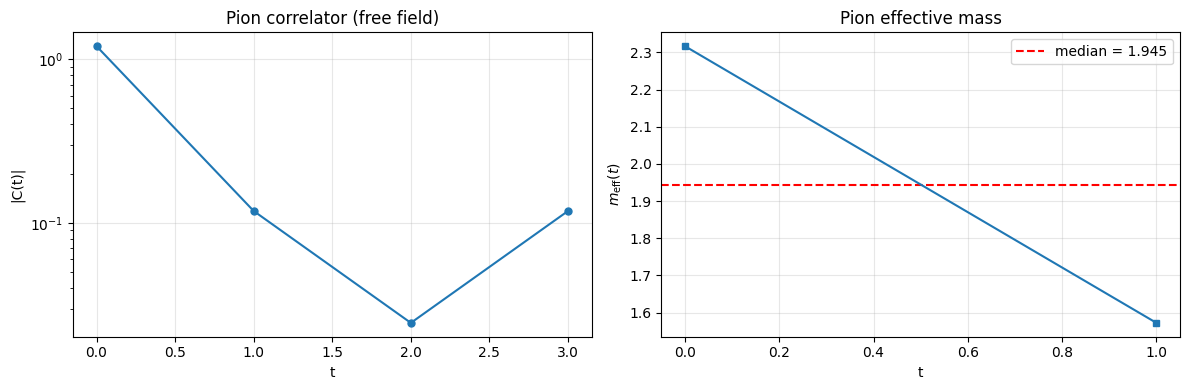

Extracted pion mass: 1.5725 +/- 0.3145
Effective mass = m + 4r = 2.2000


In [5]:
# Plot correlator and effective mass
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

plot_correlator(result['correlator'], title='Pion correlator (free field)', ax=ax1)
plot_effective_mass(result['correlator'], title='Pion effective mass', ax=ax2)

plt.tight_layout()
plt.show()

print(f"Extracted pion mass: {result['meson_mass']:.4f} +/- {result['meson_error']:.4f}")
print(f"Effective mass = m + 4r = {mass + 4*wilson_r:.4f}")

### Reading the correlator

The left panel shows the same **cosh-like** shape we saw for the raw
propagator in Notebook 08. On a finite lattice with antiperiodic
boundary conditions in time, the correlator picks up both a forward-
and a backward-propagating piece:
$$C(t) \;\sim\; A\,e^{-M t} \;+\; A\,e^{-M(L_t - t)}$$

so it decays from $t = 0$, hits a minimum near $t = L_t/2$, and curves
back up toward $t = L_t - 1$. With only $L_t = 4$ time slices this
shape is coarse, but the minimum at $t = 2$ and upturn at $t = 3$ are
clearly visible.

The right panel shows the **effective mass** $m_{\rm eff}(t) = \ln[C(t)/C(t+1)]$.
A flat plateau means the ground state dominates — but with only 3
data points ($t = 0, 1, 2$) we barely have enough room for excited states
to die off. The "very small $\chi^2$" warning comes from fitting a
constant to essentially one useful point ($t = 2$). On a larger lattice
the plateau would be much cleaner.

**Note:** the interacting pion correlator in Section 5 will look almost
identical in shape — that's not a bug. On a $4^4$ lattice the cosh
boundary wrapping dominates the visual shape regardless of the gauge
background. The physics difference shows up in the *mass* (the slope),
not the overall shape.

## 3. Full Spectrum ($\pi$, $\sigma$, $\rho$)

In QCD the expected mass hierarchy is $m_\pi < m_\rho < m_\sigma$.
The pion is light because it's a (pseudo-)Goldstone boson of chiral symmetry.
*See High Energy Physics Essentials §9.3.1 for the chiral-perturbation-theory argument behind this hierarchy; the pion mass enters the leading-order chiral Lagrangian via the leading-order $m_\pi^2 = 2\mu m$ relation in Ch. 9.*

In [6]:
channels = ['pion', 'sigma', 'rho_x', 'rho_y', 'rho_z']
results = {}

for ch in channels:
    r = calculate_meson_mass(U_free, mass, ch, La,
                            wilson_r=wilson_r, verbose=False)
    results[ch] = r
    print(f"{ch:8s}: M = {r['meson_mass']:.4f} +/- {r['meson_error']:.4f}")

pion    : M = 1.5725 +/- 0.3145


sigma   : M = 1.5279 +/- 0.3056


rho_x   : M = 1.5215 +/- 0.3043


rho_y   : M = 1.5215 +/- 0.3043


rho_z   : M = 1.5215 +/- 0.3043


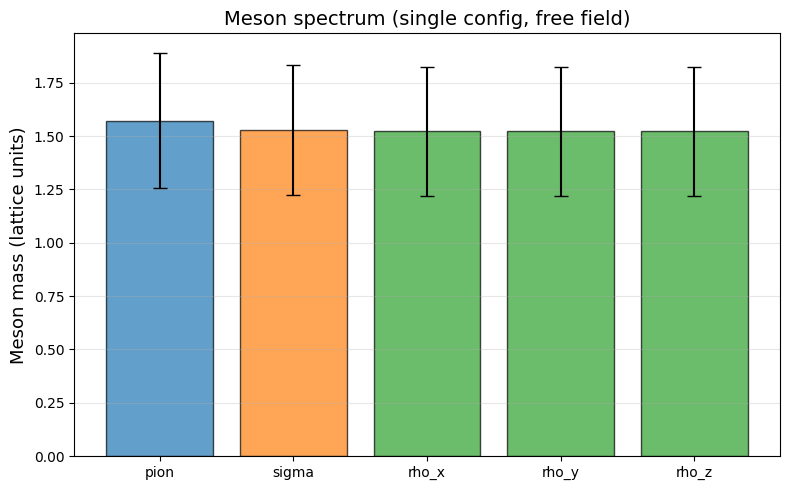

In [7]:
# Visualize the spectrum
names = list(results.keys())
masses = [results[ch]['meson_mass'] for ch in names]
errors = [results[ch]['meson_error'] for ch in names]

plt.figure(figsize=(8, 5))
plt.bar(names, masses, yerr=errors, capsize=5, alpha=0.7,
        color=['C0', 'C1', 'C2', 'C2', 'C2'], edgecolor='k')
plt.ylabel('Meson mass (lattice units)', fontsize=13)
plt.title('Meson spectrum (single config, free field)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### What do we expect here?

On the **free field** (identity gauge links), there are no gluon interactions
to split the meson states, so all channels should have roughly the same mass:
$M_\pi \approx M_\sigma \approx M_\rho$. That near-degeneracy is exactly
what we see above.

The three $\rho$ polarizations ($\rho_x$, $\rho_y$, $\rho_z$) should be
**exactly degenerate** on the free field — the $4^4$ lattice has full
cubic symmetry and all three spatial directions are equivalent (periodic
boundary conditions, same extent). Any splitting between them would
signal a convention mismatch between the gamma matrices used in the meson
operators and those used in the Dirac operator. (The vector bilinear
$V_\mu = \bar\psi\gamma_\mu\psi$ is the irrep used here; see High Energy Physics Essentials Ch. 6 and Exercise 6.45 for its rotation properties.)

**Convention note:** the Dirac operator in `build_wilson_dirac_matrix`
maps `gamma[mu]` to lattice direction $\mu$ with
$[\mu=0,1,2,3] \leftrightarrow [x,y,z,t]$.
So the three *spatial* gammas are $\gamma_0, \gamma_1, \gamma_2$ and the
*temporal* gamma is $\gamma_3$. The rho polarizations use these spatial
gammas: $\rho_x \to \gamma_0$, $\rho_y \to \gamma_1$, $\rho_z \to \gamma_2$.
Accidentally using $\gamma_3$ (temporal) for a spatial polarization would
break the degeneracy because the time direction has antiperiodic boundary
conditions while spatial directions are periodic.

## 4. $M_\pi^2$ vs $m_q$: The GMOR Relation

The **Gell-Mann--Oakes--Renner** (GMOR) relation is one of the most important
results connecting chiral symmetry to hadron physics:
$$M_\pi^2 = \frac{2\,m_q\,|\langle\bar\psi\psi\rangle|}{f_\pi^2}$$
(High Energy Physics Essentials Ch. 9 gives the leading-order chiral-Lagrangian form
$m_\pi^2 = 2\mu m$; identifying the low-energy constant $\mu \propto |\langle\bar\psi\psi\rangle|/f_\pi^2$ recovers the form above. See §9.3.1.)

The key prediction is linearity: $M_\pi^2 \propto m_q$.
This is a hallmark of the pion being a **pseudo-Goldstone boson** of
spontaneously broken chiral symmetry.
As $m_q \to 0$, the pion becomes massless (the Goldstone limit).

In [8]:
quark_masses = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
pion_masses = []

for mq in quark_masses:
    r = calculate_meson_mass(U_free, mq, 'pion', La,
                            wilson_r=wilson_r, verbose=False)
    pion_masses.append(r['meson_mass'])
    print(f"  m_q = {mq:.2f} -> M_pi = {r['meson_mass']:.4f}")

mq_arr = np.array(quark_masses)
mp_arr = np.array(pion_masses)

  m_q = 0.05 -> M_pi = 1.6050


  m_q = 0.10 -> M_pi = 1.5804


  m_q = 0.15 -> M_pi = 1.5701


  m_q = 0.20 -> M_pi = 1.5725


  m_q = 0.30 -> M_pi = 1.6078


  m_q = 0.40 -> M_pi = 1.6726


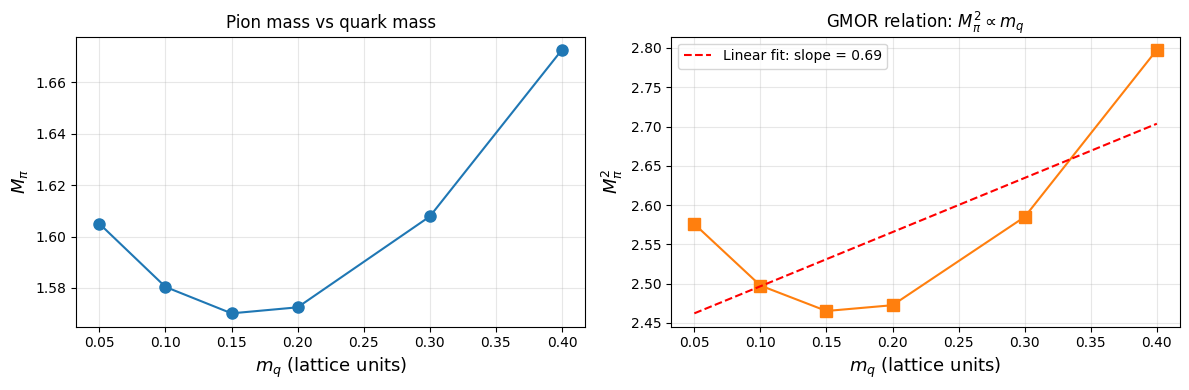

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# M_pi vs m_q
ax1.plot(mq_arr, mp_arr, 'o-', markersize=8)
ax1.set_xlabel(r'$m_q$ (lattice units)', fontsize=13)
ax1.set_ylabel(r'$M_\pi$', fontsize=13)
ax1.set_title(r'Pion mass vs quark mass')
ax1.grid(True, alpha=0.3)

# M_pi^2 vs m_q (should be linear per GMOR)
ax2.plot(mq_arr, mp_arr**2, 's-', markersize=8, color='C1')
# Linear fit
coeffs = np.polyfit(mq_arr, mp_arr**2, 1)
ax2.plot(mq_arr, np.polyval(coeffs, mq_arr), 'r--',
         label=f'Linear fit: slope = {coeffs[0]:.2f}')
ax2.set_xlabel(r'$m_q$ (lattice units)', fontsize=13)
ax2.set_ylabel(r'$M_\pi^2$', fontsize=13)
ax2.set_title(r'GMOR relation: $M_\pi^2 \propto m_q$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Why doesn't this look linear?

The GMOR relation $M_\pi^2 \propto m_q$ is a consequence of **spontaneous
chiral symmetry breaking** by the QCD vacuum — the pion is light because
it's a pseudo-Goldstone boson. But on a free field (identity gauge links)
there's no vacuum dynamics and no symmetry breaking, so the Goldstone
mechanism doesn't operate. (See High Energy Physics Essentials §9.3.1 for the
SU(2)$_L\times$SU(2)$_R \to$ SU(2)$_V$ chiral-symmetry-breaking pattern that
underlies GMOR.)

What we see instead: $M_\pi$ shows a **U-shape** rather than the monotonic
increase expected from GMOR. The pion mass dips slightly from
$m_q = 0.05$ down to a minimum around $m_q \approx 0.15$–$0.20$, then
rises again at larger masses. The overall variation is small ($\sim 6\%$)
because the **Wilson mass shift** $4r = 2.0$ dominates — the bare quark
mass range ($0.05$–$0.4$) is a small perturbation on top of that.

The U-shape itself comes from the interplay between the mass extraction
fitting (which has large systematics with only 3 effective-mass points
on this tiny lattice) and the Wilson dispersion relation. It's not
physical GMOR behavior.

To see genuine $M_\pi^2 \propto m_q$ linearity you'd need an interacting
gauge ensemble with many configurations and a larger temporal extent so
the exponential decay is well resolved.

## 5. Interacting Gauge Field

Now let's repeat the pion calculation on a non-trivial gauge background.
This is where the gluon dynamics create binding.

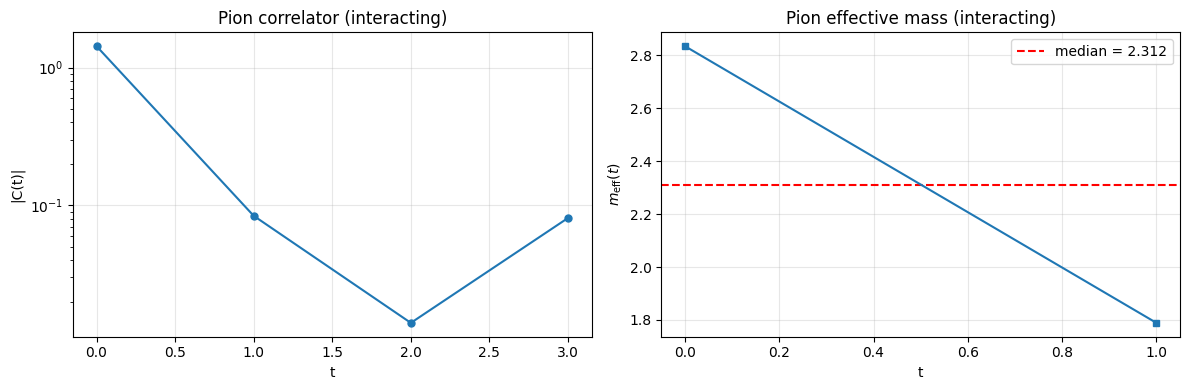

In [10]:
config_path = os.path.join(REPO, "configs", "sample_4x4x4x4",
                           "random_4x4x4x4.pkl")
U_rand, meta = load_config(config_path)
U_int = [None, U_rand]

result_int = calculate_meson_mass(U_int, 0.2, 'pion', La,
                                  wilson_r=0.5, verbose=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_correlator(result_int['correlator'],
               title='Pion correlator (interacting)', ax=ax1)
plot_effective_mass(result_int['correlator'],
                   title='Pion effective mass (interacting)', ax=ax2)
plt.tight_layout()
plt.show()

## Exercises

1. Compare the pion mass on the free-field and interacting configs.
   Why is the interacting case noisier?
2. **Same quarks, different spin**: The pion ($J^{PC} = 0^{-+}$), sigma
   ($0^{++}$), and rho ($1^{--}$) are all built from the **same
   quark-antiquark content** $\bar\psi\,\Gamma\,\psi$ — the only thing
   that changes between them is the Dirac matrix $\Gamma$. Explain
   physically why inserting $\gamma_5$ vs $\mathbb{1}$ vs $\gamma_i$
   produces states with different spin and parity, and trace through
   how $\Gamma$ appears on both sides of the Wick contraction so that
   the quantum numbers are preserved in the correlator.
3. **Light quark limit**: Change the quark mass from 0.2 to 0.05 — lighter
   quarks give a lighter pion (GMOR relation). How does the correlator
   signal-to-noise change?
4. **Wilson parameter shift**: Change `wilson_r` from 0.5 to 1.0 and
   recompute the pion mass. The effective mass shifts by $4\Delta r$ —
   verify this quantitatively.
5. Calculate $M_\sigma / M_\pi$ on the free field.
   How does this ratio compare to the real-world value ($\approx 4$)?
6. Compute the rho mass for all 3 polarizations ($\rho_x, \rho_y, \rho_z$).
   Are they degenerate? What breaks rotational symmetry on a single config?
7. Plot $M_\pi, M_\sigma, M_\rho$ as a function of $m_q$.
   Which particle is always lightest?
8. **Chiral limit exploration**: Add more quark masses (e.g., 0.01, 0.02)
   to the GMOR scan in Section 4 to probe closer to the chiral limit.
   Very small masses may give noisy or unstable correlators on a small
   lattice — at what mass does the signal break down?
9. **GMOR quantitative fit**: Using the mass scan data from Section 4,
   fit $M_\pi^2 = c_0 + c_1 \cdot m_q$ with `np.polyfit`.
   The $x$-intercept $m_{\rm crit} = -c_0/c_1$ is where $M_\pi \to 0$.
   For Wilson fermions, $m_{\rm crit} \neq 0$ due to additive renormalization.
   Compare your value to the free-field expectation $m_{\rm crit} = -4r$.
10. **Excited state contamination**: In the effective mass plot from Section 2,
    identify the region where $m_{\rm eff}(t)$ is still decreasing (excited
    states contribute). At what $t$ does the plateau begin?
    Try fitting only $t \geq 2$ vs $t \geq 1$ — how does the extracted
    mass change? A robust extraction requires the plateau to be stable
    under variations of $t_{\min}$.